In [1]:
from pathlib import Path

BASE_DIR = Path("e4_artifacts")
LOG_DIR = BASE_DIR / "logs"
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"
REPORT_DIR = BASE_DIR / "reports"

for folder in [BASE_DIR, LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Созданы папки:")
for folder in [LOG_DIR, TABLE_DIR, FIG_DIR, REPORT_DIR]:
    print(folder.resolve())

Созданы папки:
/content/e4_artifacts/logs
/content/e4_artifacts/tables
/content/e4_artifacts/figures
/content/e4_artifacts/reports


In [2]:
import pandas as pd

TRAIN_PATH = "train_final.csv"
TEST_PATH = "test_final.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

train_df shape: (7957, 3)
test_df shape: (2211, 3)


,text,label,id
0,@YELLEZ @WylsacomRed Почему бы просто не купит...,neutral,1215652526319722501
1,"посмотрите кто-нибудь ""импровизацию""..\r\nя хо...",positive,1341141182093668352
2,@robodeacon зашел сфоткаться с кастом тени и к...,neutral,1234077503993581569
3,Моя оформа: /меняется на чёрно-белую/\r\n\r\nМ...,neutral,1326075120465702912
4,сижу в такси рядом ползает паук няшка,positive,1276191130535821315


,text,label,id
0,я считаю это мем года https://t.co/xoVKj5y8Mj,positive,1218052288964632576
1,ян русский на сотку все запятые где надо🤙🏻👍🏻👍🏻...,positive,1212859589592539136
2,@daria_karapet * терияки бойз начинает играть*,neutral,1321540138334302209
3,(пушка на Караульной горе больше не стреляет Б...,negative,1342696727808274432
4,@Iori_loves_U Как мило /смутилась/ спасибо 🥰🌸,positive,1317052132382679041


In [3]:
SEED = 42

X_train = train_df["text"].copy()
y_train = train_df["label"].copy()

X_test = test_df["text"].copy()
y_test = test_df["label"].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (7957,)
y_train: (7957,)
X_test: (2211,)
y_test: (2211,)


In [4]:
import json

E4_CONFIG = {
    "experiment": "E4 class balancing study",
    "dataset": "RuSentiTweet",
    "train_file": TRAIN_PATH,
    "test_file": TEST_PATH,
    "seed": SEED,
    "representation": {
        "type": "TfidfVectorizer",
        "lowercase": True,
        "analyzer": "char_wb",
        "ngram_range": (3, 5),
        "min_df": 2,
        "max_df": 0.95
    },
    "models": [
        "SGDClassifier hinge",
        "Linear SVM",
        "RidgeClassifier"
    ],
    "modes": [
        "default",
        "balanced"
    ]
}

with open(LOG_DIR / "e4_config.json", "w", encoding="utf-8") as f:
    json.dump(E4_CONFIG, f, ensure_ascii=False, indent=4)

print("Saved:", LOG_DIR / "e4_config.json")

Saved: e4_artifacts/logs/e4_config.json


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

char_vectorizer = TfidfVectorizer(
    lowercase=True,
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95
)

X_train_char = char_vectorizer.fit_transform(X_train)
X_test_char = char_vectorizer.transform(X_test)

print("X_train_char shape:", X_train_char.shape)
print("X_test_char shape:", X_test_char.shape)

X_train_char shape: (7957, 78069)
X_test_char shape: (2211, 78069)


In [6]:
import time
from sklearn.linear_model import SGDClassifier, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [7]:
e4_results = []
e4_per_class_rows = []

In [8]:
def evaluate_model(
    model,
    model_family,
    class_weight_mode,
    X_train_mat,
    y_train,
    X_test_mat,
    y_test,
    report_filename
):
    start_time = time.time()
    model.fit(X_train_mat, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test_mat)

    acc = accuracy_score(y_test, y_pred)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )
    f1_macro = f1_score(y_test, y_pred, average="macro")

    report_text = classification_report(y_test, y_pred, digits=4, zero_division=0)
    report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    with open(REPORT_DIR / report_filename, "w", encoding="utf-8") as f:
        f.write(report_text)

    result = {
        "model_family": model_family,
        "model": f"{model_family} ({class_weight_mode})",
        "class_weight_mode": class_weight_mode,
        "representation": "char TF-IDF (3,5)",
        "accuracy": round(acc, 4),
        "precision_weighted": round(precision_w, 4),
        "recall_weighted": round(recall_w, 4),
        "weighted_f1": round(f1_w, 4),
        "macro_f1": round(f1_macro, 4),
        "train_time_sec": round(train_time, 4),
        "seed": SEED
    }

    per_class_rows = []
    for cls in ["negative", "neutral", "positive"]:
        per_class_rows.append({
            "model_family": model_family,
            "class_weight_mode": class_weight_mode,
            "representation": "char TF-IDF (3,5)",
            "class": cls,
            "precision": round(report_dict[cls]["precision"], 4),
            "recall": round(report_dict[cls]["recall"], 4),
            "f1": round(report_dict[cls]["f1-score"], 4),
            "support": int(report_dict[cls]["support"])
        })

    return result, y_pred, report_text, per_class_rows

In [9]:
sgd_default = SGDClassifier(
    loss="hinge",
    max_iter=1000,
    tol=1e-3,
    random_state=SEED
)

res_sgd_default, pred_sgd_default, rep_sgd_default, rows_sgd_default = evaluate_model(
    model=sgd_default,
    model_family="SGDClassifier hinge",
    class_weight_mode="default",
    X_train_mat=X_train_char,
    y_train=y_train,
    X_test_mat=X_test_char,
    y_test=y_test,
    report_filename="classification_report_sgd_hinge_default.txt"
)

e4_results.append(res_sgd_default)
e4_per_class_rows.extend(rows_sgd_default)

print(res_sgd_default)
print(rep_sgd_default)

{'model_family': 'SGDClassifier hinge', 'model': 'SGDClassifier hinge (default)', 'class_weight_mode': 'default', 'representation': 'char TF-IDF (3,5)', 'accuracy': 0.682, 'precision_weighted': 0.6854, 'recall_weighted': 0.682, 'weighted_f1': 0.6741, 'macro_f1': 0.6517, 'train_time_sec': 0.473, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6748    0.5848    0.6266       660
     neutral     0.6751    0.8287    0.7440      1068
    positive     0.7226    0.4907    0.5845       483

    accuracy                         0.6820      2211
   macro avg     0.6908    0.6347    0.6517      2211
weighted avg     0.6854    0.6820    0.6741      2211



In [10]:
sgd_balanced = SGDClassifier(
    loss="hinge",
    max_iter=1000,
    tol=1e-3,
    class_weight="balanced",
    random_state=SEED
)

res_sgd_balanced, pred_sgd_balanced, rep_sgd_balanced, rows_sgd_balanced = evaluate_model(
    model=sgd_balanced,
    model_family="SGDClassifier hinge",
    class_weight_mode="balanced",
    X_train_mat=X_train_char,
    y_train=y_train,
    X_test_mat=X_test_char,
    y_test=y_test,
    report_filename="classification_report_sgd_hinge_balanced.txt"
)

e4_results.append(res_sgd_balanced)
e4_per_class_rows.extend(rows_sgd_balanced)

print(res_sgd_balanced)
print(rep_sgd_balanced)

{'model_family': 'SGDClassifier hinge', 'model': 'SGDClassifier hinge (balanced)', 'class_weight_mode': 'balanced', 'representation': 'char TF-IDF (3,5)', 'accuracy': 0.6703, 'precision_weighted': 0.6678, 'recall_weighted': 0.6703, 'weighted_f1': 0.6683, 'macro_f1': 0.6488, 'train_time_sec': 0.5682, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6405    0.6182    0.6291       660
     neutral     0.7069    0.7519    0.7287      1068
    positive     0.6187    0.5611    0.5885       483

    accuracy                         0.6703      2211
   macro avg     0.6554    0.6437    0.6488      2211
weighted avg     0.6678    0.6703    0.6683      2211



In [15]:
svm_default = LinearSVC(
    random_state=SEED
)

res_svm_default, pred_svm_default, rep_svm_default, rows_svm_default = evaluate_model(
    model=svm_default,
    model_family="Linear SVM",
    class_weight_mode="default",
    X_train_mat=X_train_char,
    y_train=y_train,
    X_test_mat=X_test_char,
    y_test=y_test,
    report_filename="classification_report_svm_default.txt"
)

e4_results.append(res_svm_default)
e4_per_class_rows.extend(rows_svm_default)

print(res_svm_default)
print(rep_svm_default)

{'model_family': 'Linear SVM', 'model': 'Linear SVM (default)', 'class_weight_mode': 'default', 'representation': 'char TF-IDF (3,5)', 'accuracy': 0.6716, 'precision_weighted': 0.6707, 'recall_weighted': 0.6716, 'weighted_f1': 0.6662, 'macro_f1': 0.6452, 'train_time_sec': 0.6899, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6479    0.5939    0.6198       660
     neutral     0.6812    0.7921    0.7325      1068
    positive     0.6786    0.5114    0.5832       483

    accuracy                         0.6716      2211
   macro avg     0.6692    0.6325    0.6452      2211
weighted avg     0.6707    0.6716    0.6662      2211



In [11]:
svm_balanced = LinearSVC(
    class_weight="balanced",
    random_state=SEED
)

res_svm_balanced, pred_svm_balanced, rep_svm_balanced, rows_svm_balanced = evaluate_model(
    model=svm_balanced,
    model_family="Linear SVM",
    class_weight_mode="balanced",
    X_train_mat=X_train_char,
    y_train=y_train,
    X_test_mat=X_test_char,
    y_test=y_test,
    report_filename="classification_report_svm_balanced.txt"
)

e4_results.append(res_svm_balanced)
e4_per_class_rows.extend(rows_svm_balanced)

print(res_svm_balanced)
print(rep_svm_balanced)

{'model_family': 'Linear SVM', 'model': 'Linear SVM (balanced)', 'class_weight_mode': 'balanced', 'representation': 'char TF-IDF (3,5)', 'accuracy': 0.6707, 'precision_weighted': 0.6684, 'recall_weighted': 0.6707, 'weighted_f1': 0.6678, 'macro_f1': 0.6484, 'train_time_sec': 0.844, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6381    0.6197    0.6287       660
     neutral     0.6973    0.7612    0.7278      1068
    positive     0.6460    0.5404    0.5885       483

    accuracy                         0.6707      2211
   macro avg     0.6605    0.6404    0.6484      2211
weighted avg     0.6684    0.6707    0.6678      2211



In [12]:
ridge_default = RidgeClassifier()

res_ridge_default, pred_ridge_default, rep_ridge_default, rows_ridge_default = evaluate_model(
    model=ridge_default,
    model_family="RidgeClassifier",
    class_weight_mode="default",
    X_train_mat=X_train_char,
    y_train=y_train,
    X_test_mat=X_test_char,
    y_test=y_test,
    report_filename="classification_report_ridge_default.txt"
)

e4_results.append(res_ridge_default)
e4_per_class_rows.extend(rows_ridge_default)

print(res_ridge_default)
print(rep_ridge_default)

{'model_family': 'RidgeClassifier', 'model': 'RidgeClassifier (default)', 'class_weight_mode': 'default', 'representation': 'char TF-IDF (3,5)', 'accuracy': 0.6712, 'precision_weighted': 0.6743, 'recall_weighted': 0.6712, 'weighted_f1': 0.6622, 'macro_f1': 0.6382, 'train_time_sec': 0.4715, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6697    0.5652    0.6130       660
     neutral     0.6639    0.8268    0.7364      1068
    positive     0.7037    0.4720    0.5651       483

    accuracy                         0.6712      2211
   macro avg     0.6791    0.6213    0.6382      2211
weighted avg     0.6743    0.6712    0.6622      2211



In [13]:
ridge_balanced = RidgeClassifier(
    class_weight="balanced"
)

res_ridge_balanced, pred_ridge_balanced, rep_ridge_balanced, rows_ridge_balanced = evaluate_model(
    model=ridge_balanced,
    model_family="RidgeClassifier",
    class_weight_mode="balanced",
    X_train_mat=X_train_char,
    y_train=y_train,
    X_test_mat=X_test_char,
    y_test=y_test,
    report_filename="classification_report_ridge_balanced.txt"
)

e4_results.append(res_ridge_balanced)
e4_per_class_rows.extend(rows_ridge_balanced)

print(res_ridge_balanced)
print(rep_ridge_balanced)

{'model_family': 'RidgeClassifier', 'model': 'RidgeClassifier (balanced)', 'class_weight_mode': 'balanced', 'representation': 'char TF-IDF (3,5)', 'accuracy': 0.6694, 'precision_weighted': 0.6681, 'recall_weighted': 0.6694, 'weighted_f1': 0.6686, 'macro_f1': 0.6513, 'train_time_sec': 0.4589, 'seed': 42}
              precision    recall  f1-score   support

    negative     0.6244    0.6197    0.6221       660
     neutral     0.7152    0.7360    0.7254      1068
    positive     0.6236    0.5901    0.6064       483

    accuracy                         0.6694      2211
   macro avg     0.6544    0.6486    0.6513      2211
weighted avg     0.6681    0.6694    0.6686      2211



In [16]:
e4_results_df = pd.DataFrame(e4_results)
e4_results_df = e4_results_df.sort_values(by="weighted_f1", ascending=False).reset_index(drop=True)

display(e4_results_df)

,model_family,model,class_weight_mode,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,train_time_sec,seed
0,SGDClassifier hinge,SGDClassifier hinge (default),default,"char TF-IDF (3,5)",0.6820,0.6854,0.6820,0.6741,0.6517,0.4730,42
1,RidgeClassifier,RidgeClassifier (balanced),balanced,"char TF-IDF (3,5)",0.6694,0.6681,0.6694,0.6686,0.6513,0.4589,42
2,SGDClassifier hinge,SGDClassifier hinge (balanced),balanced,"char TF-IDF (3,5)",0.6703,0.6678,0.6703,0.6683,0.6488,0.5682,42
3,Linear SVM,Linear SVM (balanced),balanced,"char TF-IDF (3,5)",0.6707,0.6684,0.6707,0.6678,0.6484,0.8440,42
4,Linear SVM,Linear SVM (default),default,"char TF-IDF (3,5)",0.6716,0.6707,0.6716,0.6662,0.6452,0.6899,42
5,RidgeClassifier,RidgeClassifier (default),default,"char TF-IDF (3,5)",0.6712,0.6743,0.6712,0.6622,0.6382,0.4715,42


In [17]:
e4_results_df.to_csv(TABLE_DIR / "e4_balancing_results.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e4_balancing_results.csv")

Saved: e4_artifacts/tables/e4_balancing_results.csv


In [18]:
e4_per_class_df = pd.DataFrame(e4_per_class_rows)
display(e4_per_class_df)

,model_family,class_weight_mode,representation,class,precision,recall,f1,support
0,SGDClassifier hinge,default,"char TF-IDF (3,5)",negative,0.6748,0.5848,0.6266,660
1,SGDClassifier hinge,default,"char TF-IDF (3,5)",neutral,0.6751,0.8287,0.7440,1068
2,SGDClassifier hinge,default,"char TF-IDF (3,5)",positive,0.7226,0.4907,0.5845,483
3,SGDClassifier hinge,balanced,"char TF-IDF (3,5)",negative,0.6405,0.6182,0.6291,660
4,SGDClassifier hinge,balanced,"char TF-IDF (3,5)",neutral,0.7069,0.7519,0.7287,1068
5,SGDClassifier hinge,balanced,"char TF-IDF (3,5)",positive,0.6187,0.5611,0.5885,483
6,Linear SVM,balanced,"char TF-IDF (3,5)",negative,0.6381,0.6197,0.6287,660
7,Linear SVM,balanced,"char TF-IDF (3,5)",neutral,0.6973,0.7612,0.7278,1068
8,Linear SVM,balanced,"char TF-IDF (3,5)",positive,0.6460,0.5404,0.5885,483
9,RidgeClassifier,default,"char TF-IDF (3,5)",negative,0.6697,0.5652,0.6130,660


In [19]:
e4_per_class_df.to_csv(TABLE_DIR / "e4_per_class_f1.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e4_per_class_f1.csv")

Saved: e4_artifacts/tables/e4_per_class_f1.csv


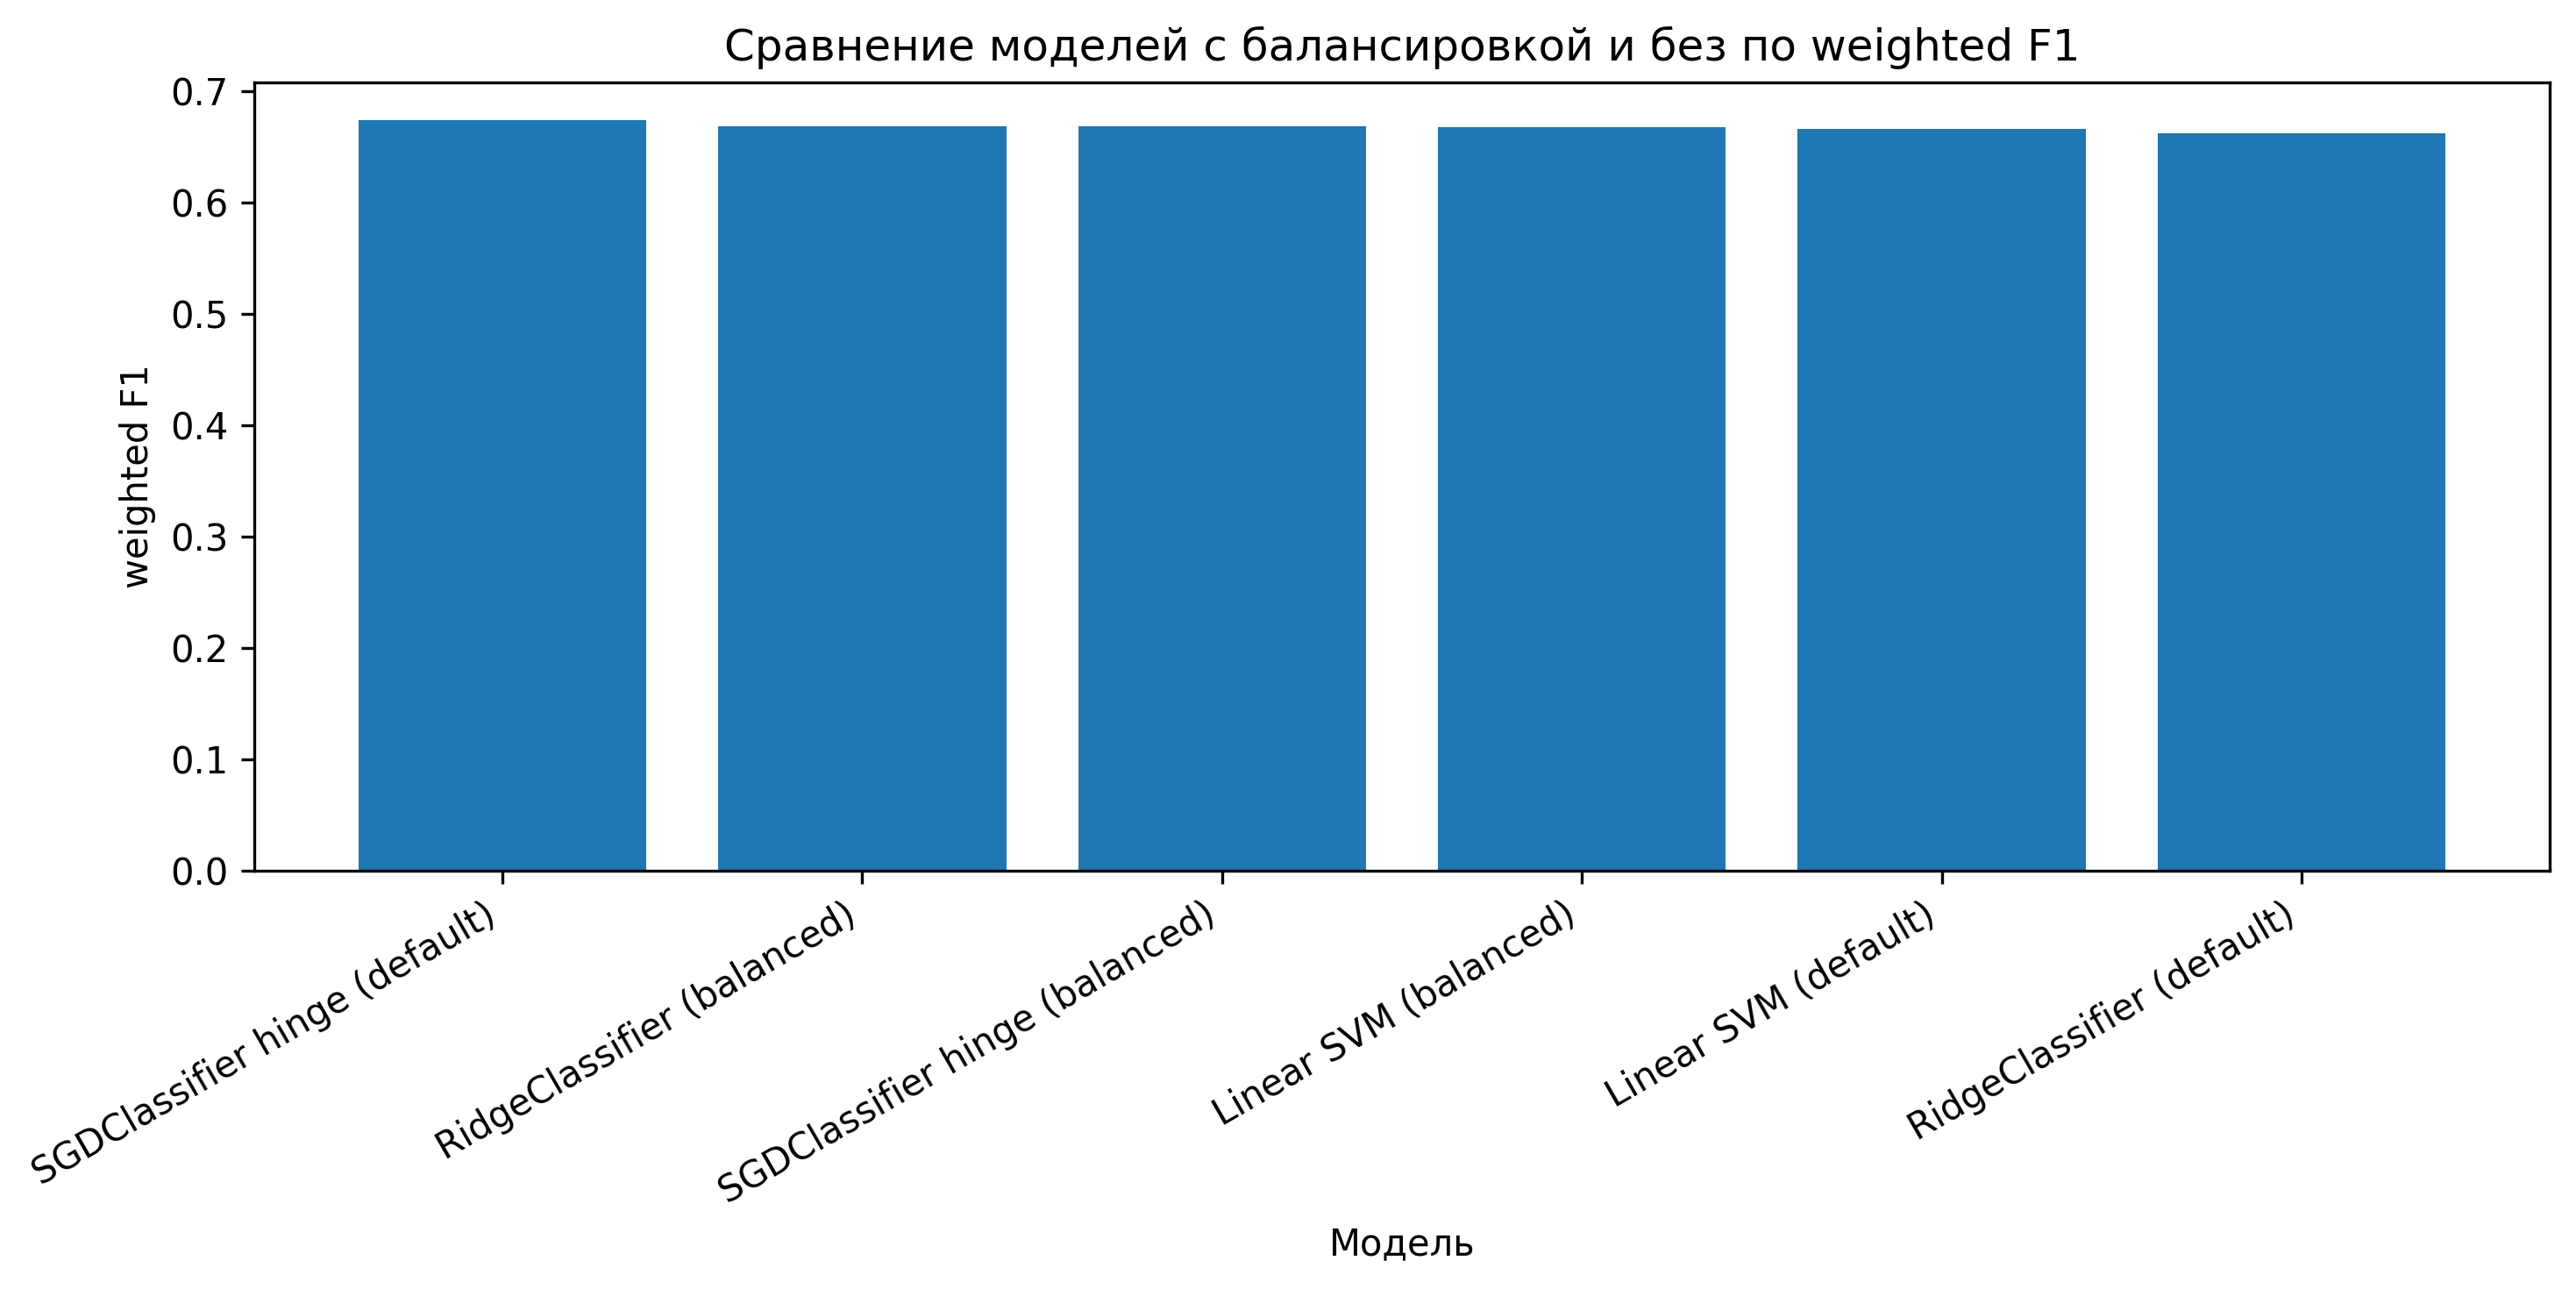

In [20]:
import matplotlib.pyplot as plt

plot_df = e4_results_df.sort_values(by="weighted_f1", ascending=False)

plt.figure(figsize=(10, 5), dpi=300)
plt.bar(plot_df["model"], plot_df["weighted_f1"])
plt.title("Сравнение моделей с балансировкой и без по weighted F1")
plt.xlabel("Модель")
plt.ylabel("weighted F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "e4_balancing_weighted_f1.png", dpi=300, bbox_inches="tight")
plt.show()

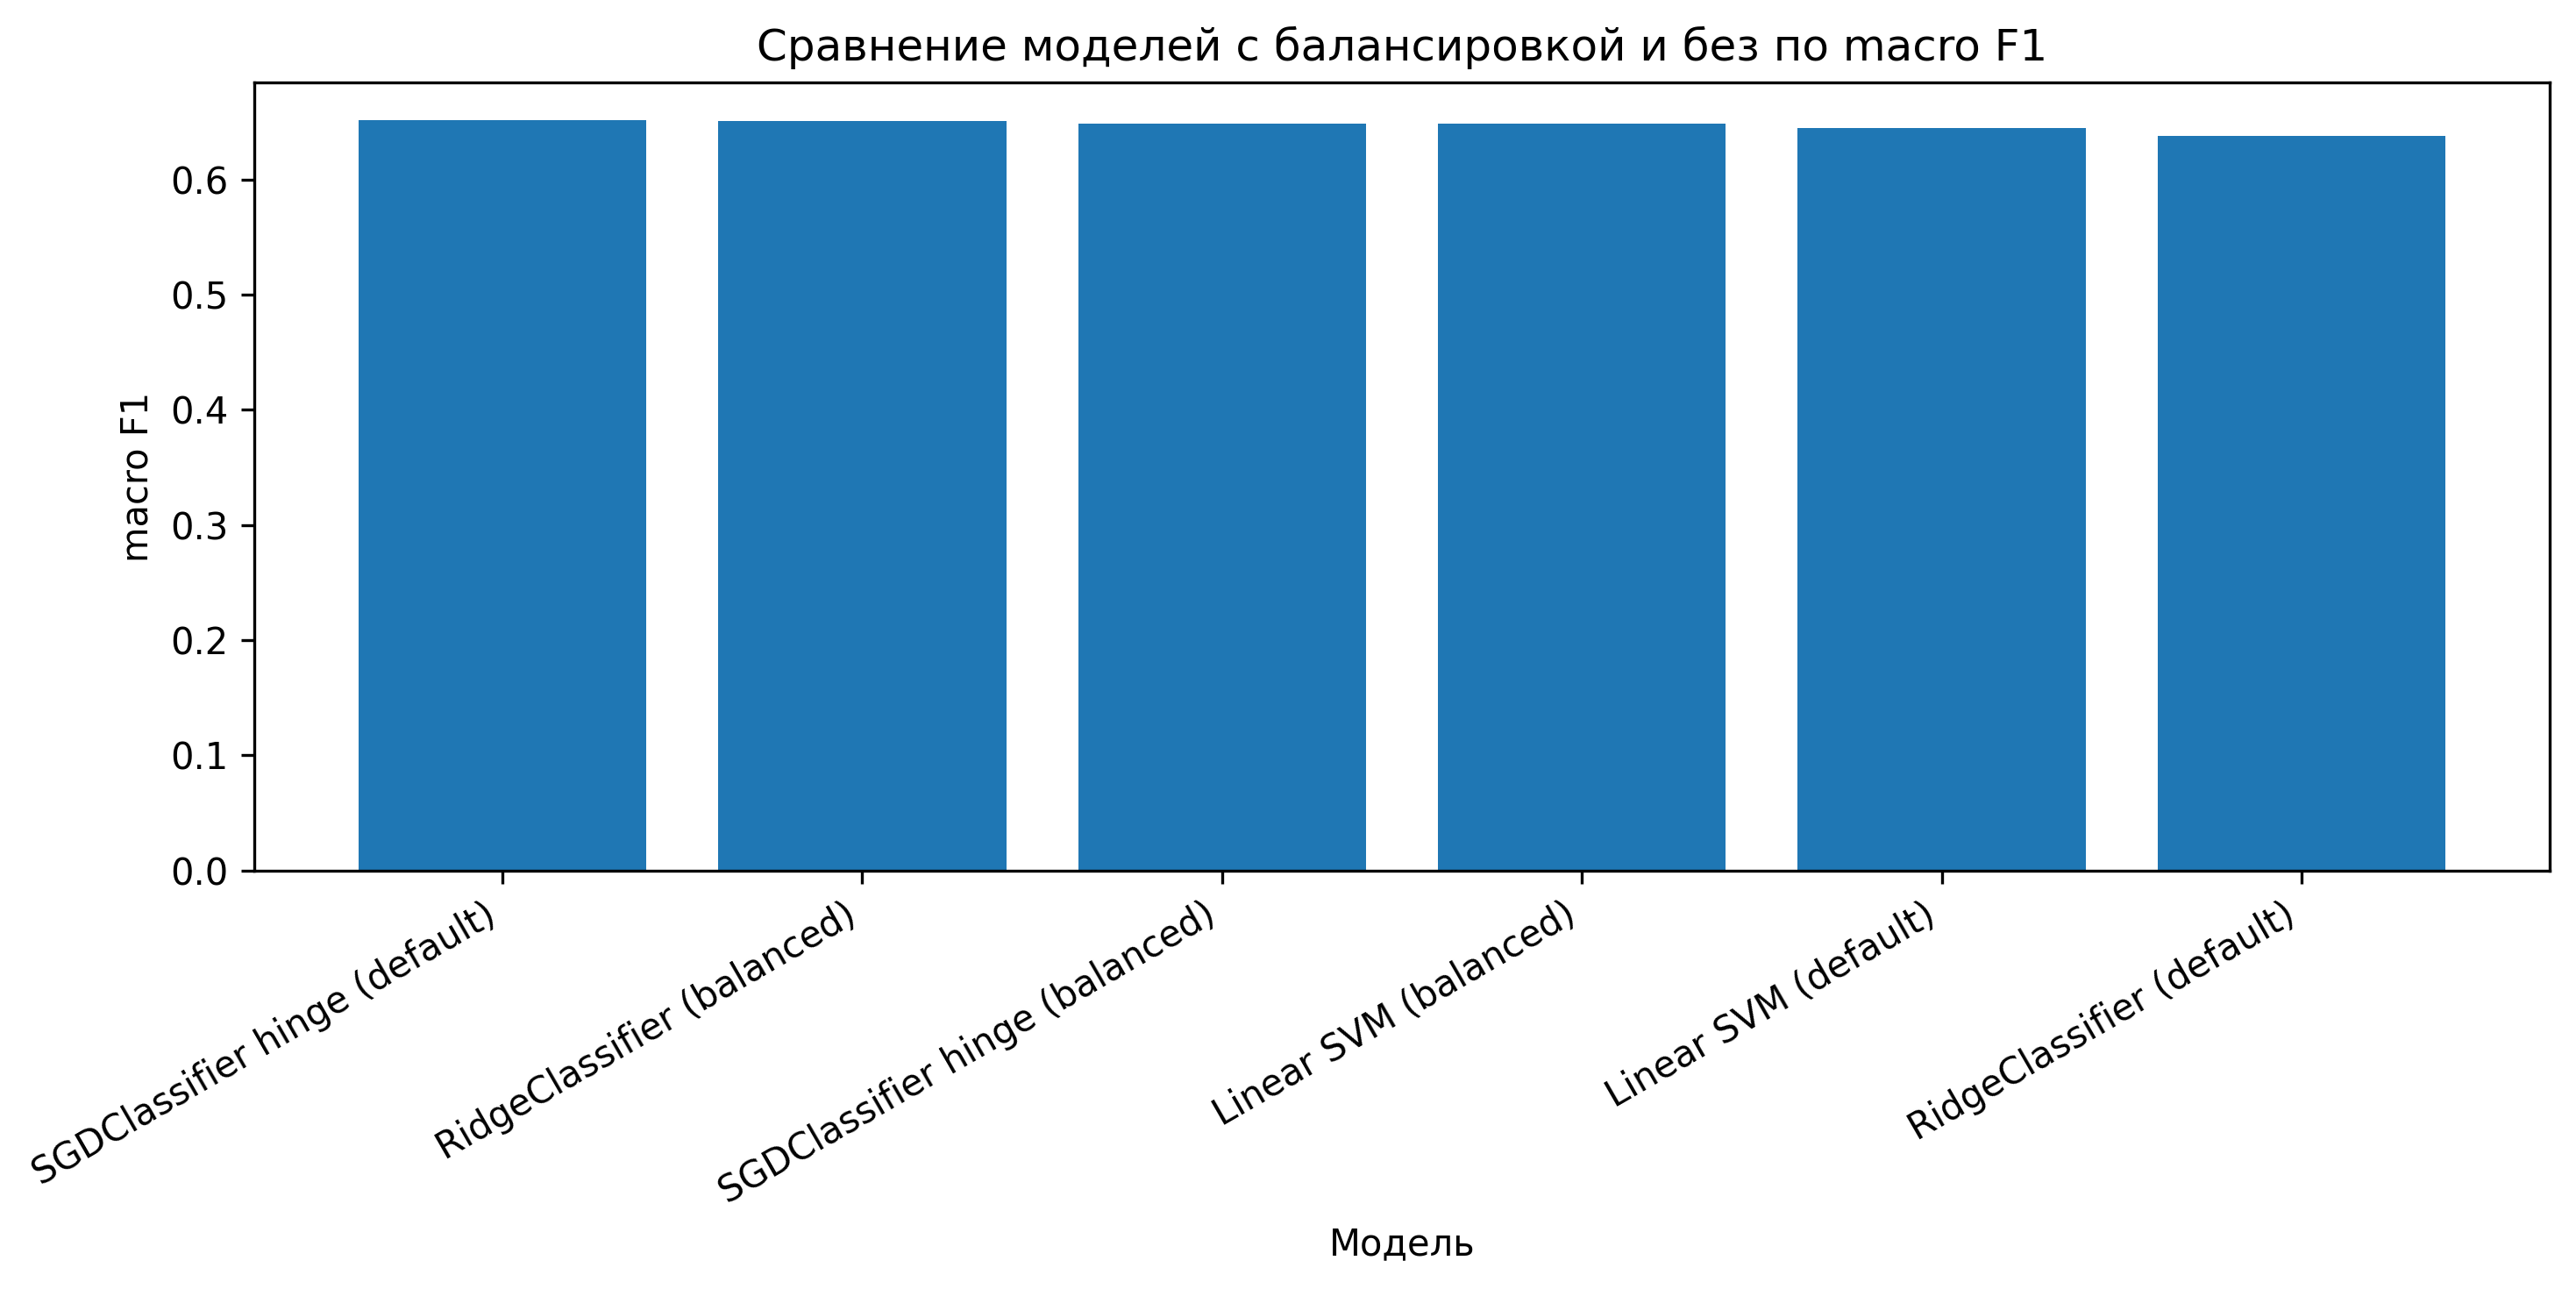

In [21]:
plot_df_macro = e4_results_df.sort_values(by="macro_f1", ascending=False)

plt.figure(figsize=(10, 5), dpi=300)
plt.bar(plot_df_macro["model"], plot_df_macro["macro_f1"])
plt.title("Сравнение моделей с балансировкой и без по macro F1")
plt.xlabel("Модель")
plt.ylabel("macro F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "e4_balancing_macro_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
pivot_gain = e4_results_df.pivot_table(
    index="model_family",
    columns="class_weight_mode",
    values="weighted_f1"
)

pivot_gain["gain"] = pivot_gain["balanced"] - pivot_gain["default"]
display(pivot_gain)

best_family_for_balance = pivot_gain["gain"].idxmax()
print("Family with largest balancing effect:", best_family_for_balance)

class_weight_mode,balanced,default,gain
model_family,,,
Linear SVM,0.6678,0.6662,0.0016
RidgeClassifier,0.6686,0.6622,0.0064
SGDClassifier hinge,0.6683,0.6741,-0.0058


Family with largest balancing effect: RidgeClassifier


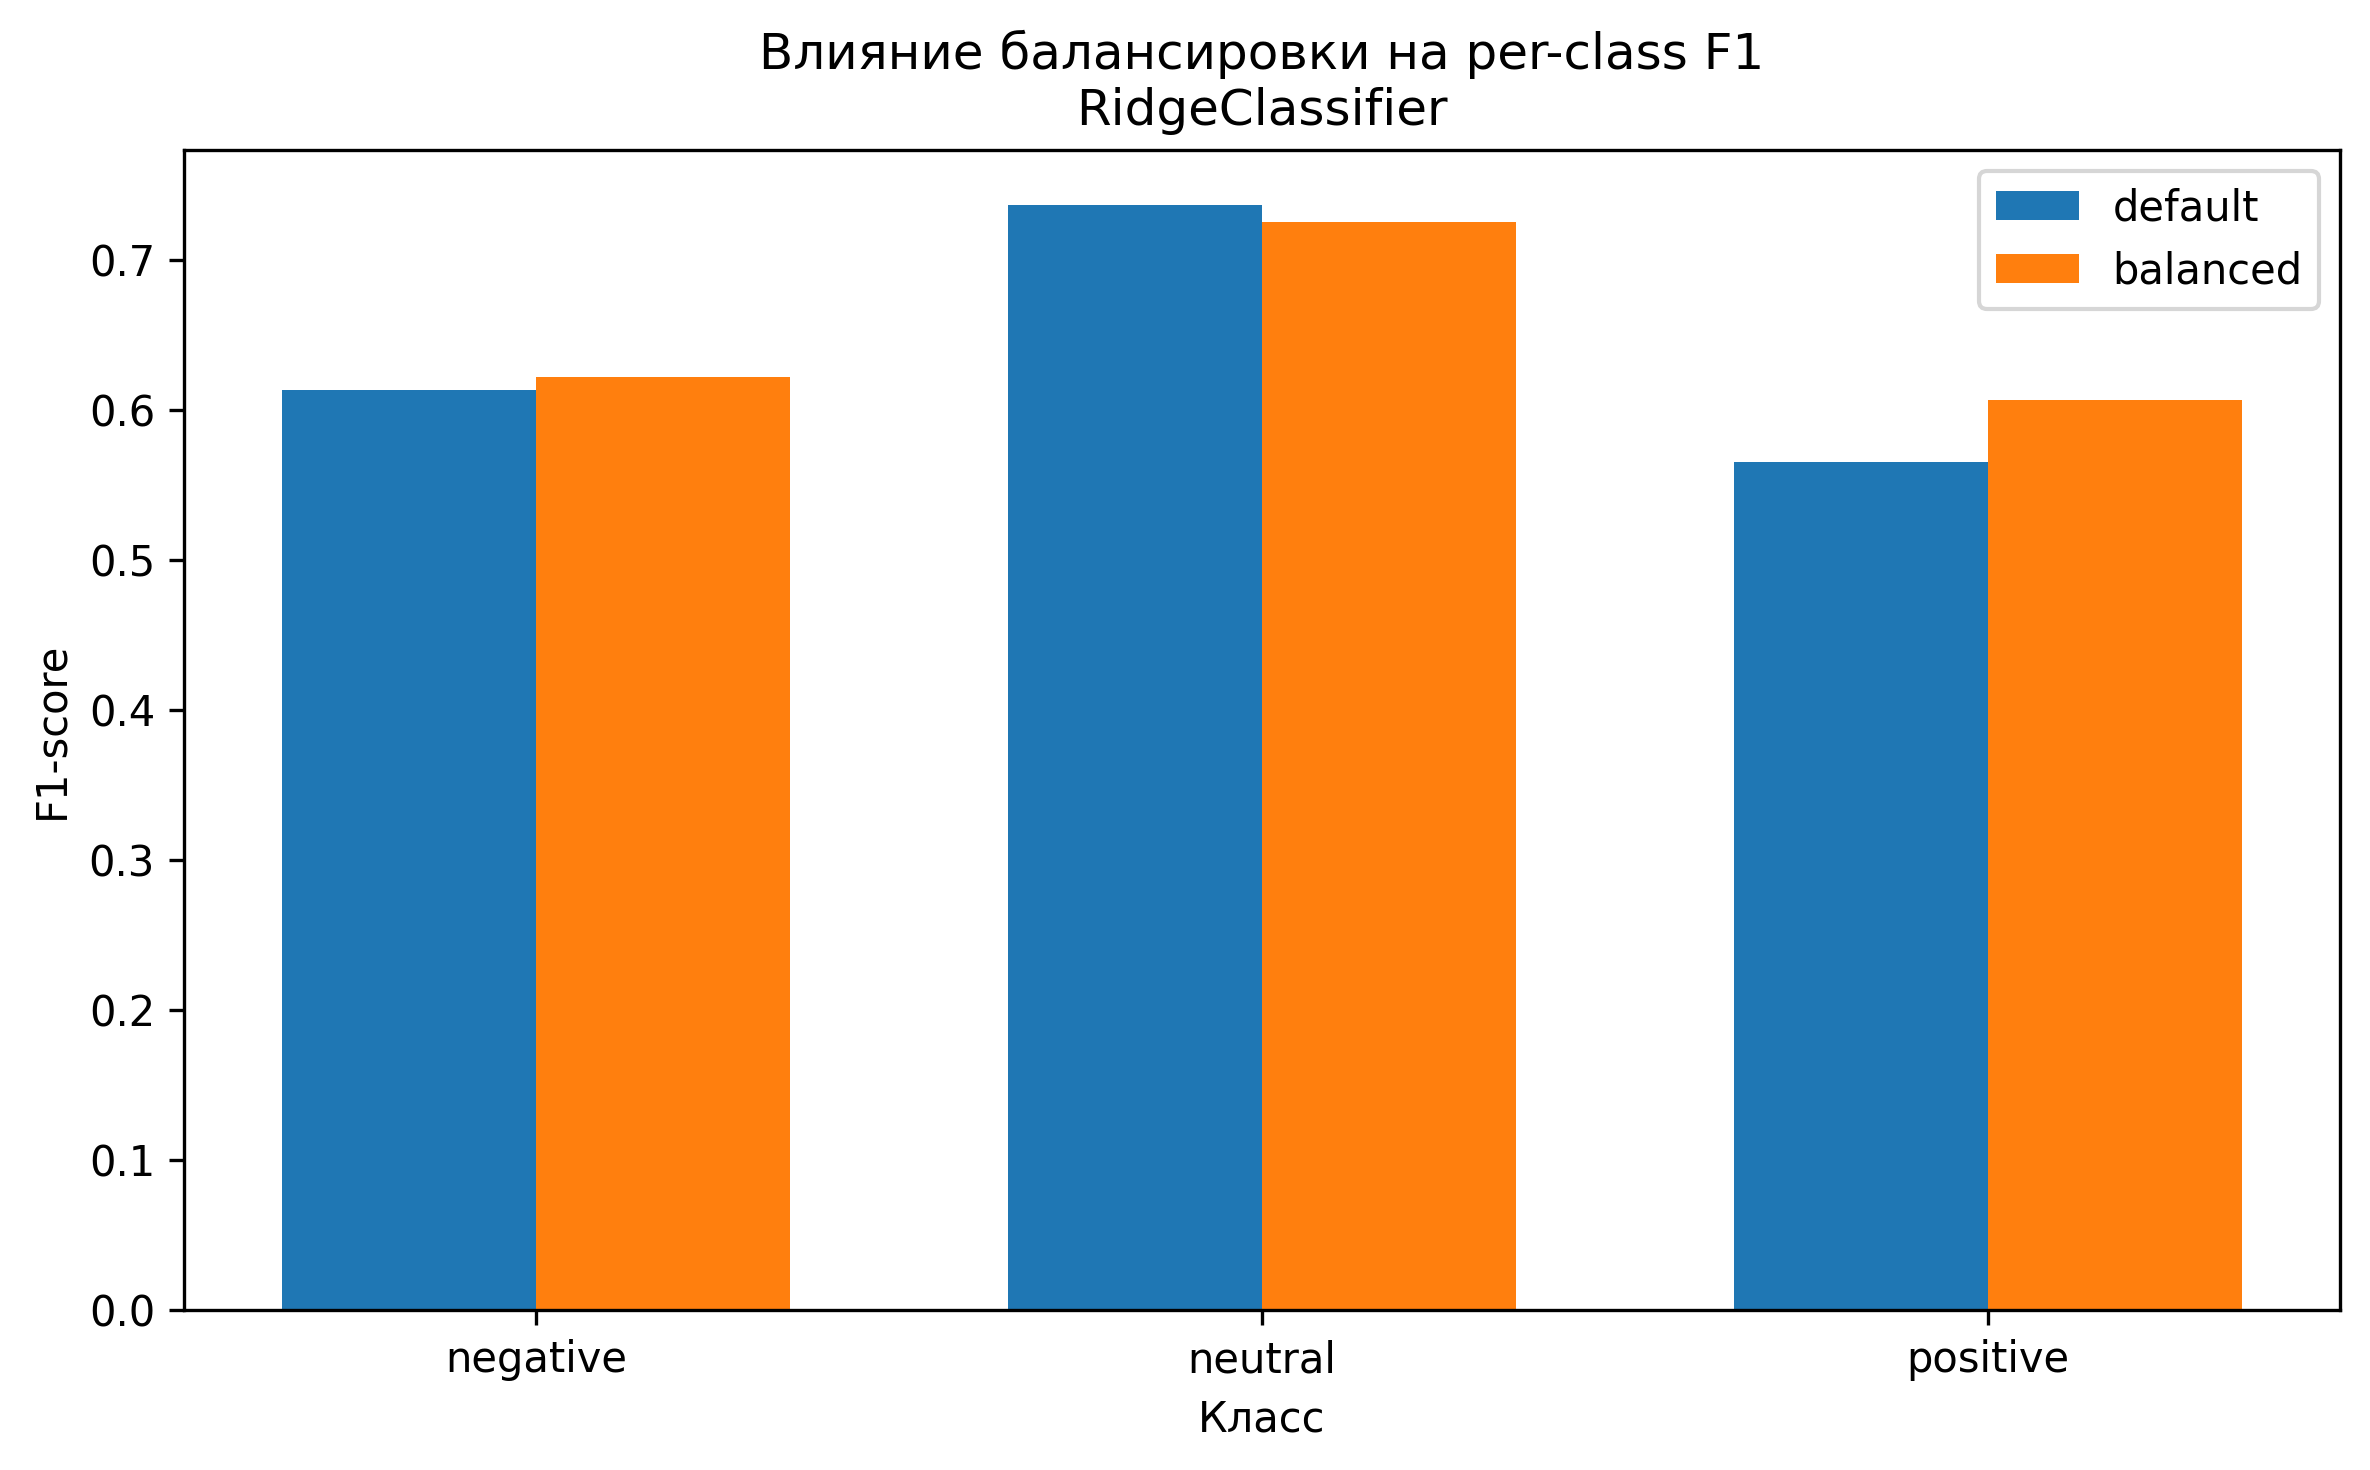

In [23]:
family_df = e4_per_class_df[e4_per_class_df["model_family"] == best_family_for_balance].copy()

pivot_family = family_df.pivot(index="class", columns="class_weight_mode", values="f1")
pivot_family = pivot_family.loc[["negative", "neutral", "positive"]]

classes = pivot_family.index.tolist()
x = range(len(classes))
width = 0.35

plt.figure(figsize=(8, 5), dpi=300)
plt.bar([i - width/2 for i in x], pivot_family["default"], width=width, label="default")
plt.bar([i + width/2 for i in x], pivot_family["balanced"], width=width, label="balanced")

plt.xticks(list(x), classes)
plt.xlabel("Класс")
plt.ylabel("F1-score")
plt.title(f"Влияние балансировки на per-class F1\n{best_family_for_balance}")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "e4_best_balance_family_per_class_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
best_e4_model_name = e4_results_df.iloc[0]["model"]
print("Best E4 model:", best_e4_model_name)

Best E4 model: SGDClassifier hinge (default)


In [25]:
predictions_map = {
    "SGDClassifier hinge (default)": pred_sgd_default,
    "SGDClassifier hinge (balanced)": pred_sgd_balanced,
    "Linear SVM (default)": pred_svm_default,
    "Linear SVM (balanced)": pred_svm_balanced,
    "RidgeClassifier (default)": pred_ridge_default,
    "RidgeClassifier (balanced)": pred_ridge_balanced
}

best_e4_pred = predictions_map[best_e4_model_name]

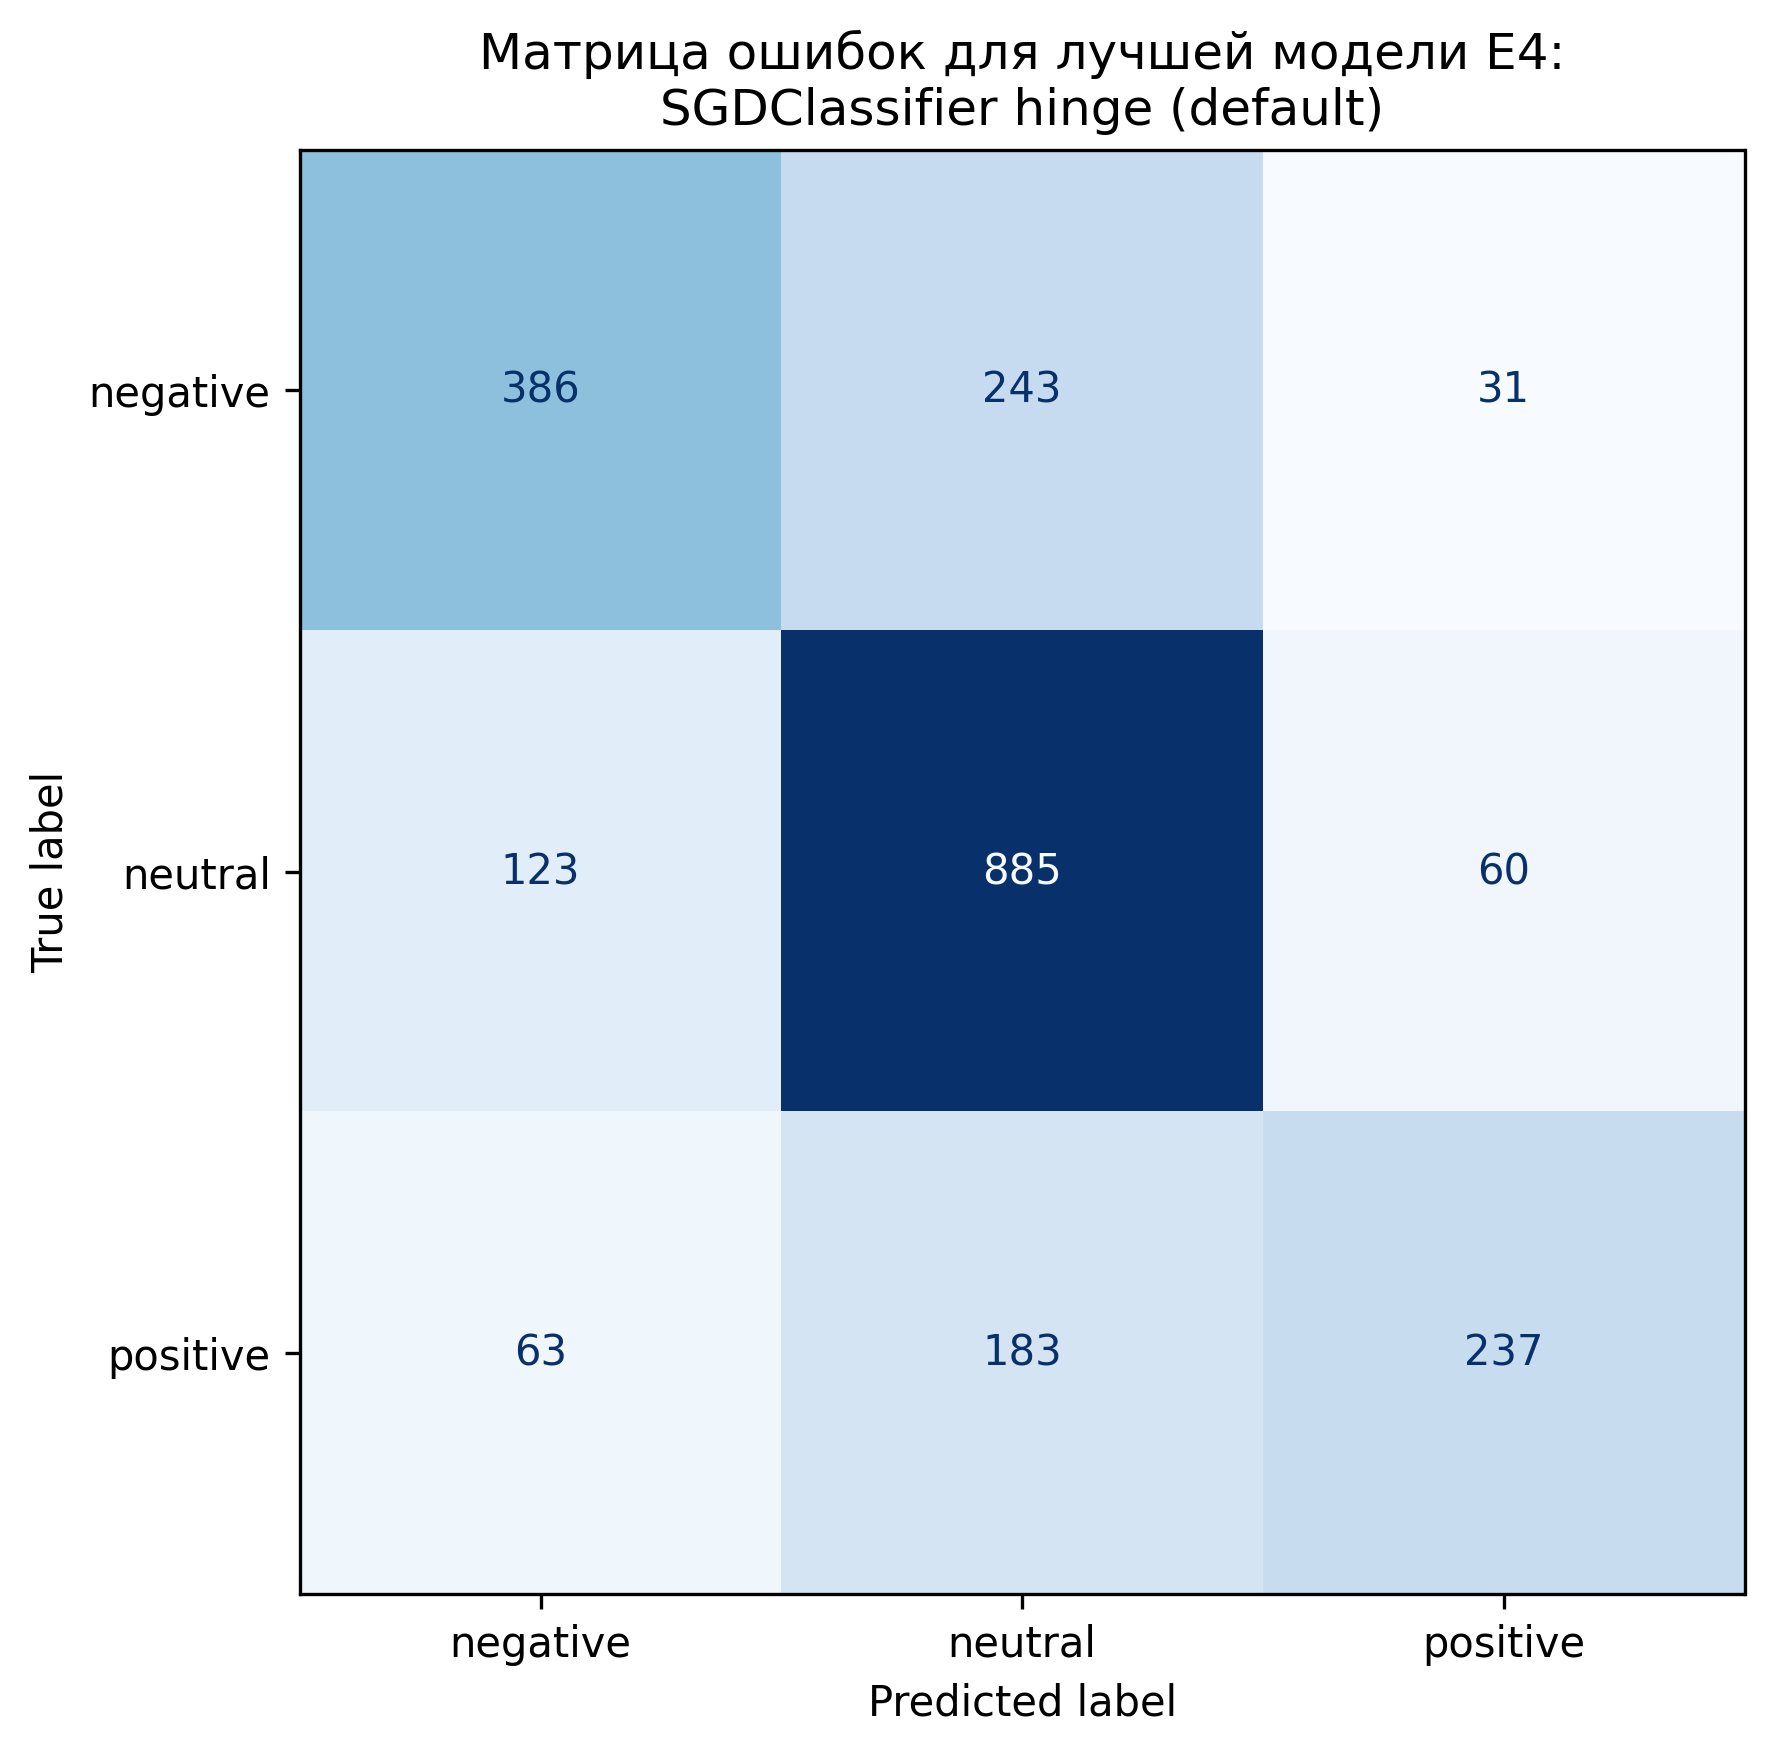

In [26]:
labels_order = ["negative", "neutral", "positive"]

cm_best_e4 = confusion_matrix(y_test, best_e4_pred, labels=labels_order)
disp_best_e4 = ConfusionMatrixDisplay(confusion_matrix=cm_best_e4, display_labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
disp_best_e4.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Матрица ошибок для лучшей модели E4:\n{best_e4_model_name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "e4_best_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
experiment_ids = [f"E4-{i+1}" for i in range(len(e4_results_df))]

e4_registry = e4_results_df.copy()
e4_registry.insert(0, "experiment_id", experiment_ids)
e4_registry["dataset"] = "RuSentiTweet"
e4_registry["train_split"] = "train_final"
e4_registry["test_split"] = "test_final"
e4_registry["status"] = "completed"

display(e4_registry)

,experiment_id,model_family,model,class_weight_mode,representation,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,train_time_sec,seed,dataset,train_split,test_split,status
0,E4-1,SGDClassifier hinge,SGDClassifier hinge (default),default,"char TF-IDF (3,5)",0.6820,0.6854,0.6820,0.6741,0.6517,0.4730,42,RuSentiTweet,train_final,test_final,completed
1,E4-2,RidgeClassifier,RidgeClassifier (balanced),balanced,"char TF-IDF (3,5)",0.6694,0.6681,0.6694,0.6686,0.6513,0.4589,42,RuSentiTweet,train_final,test_final,completed
2,E4-3,SGDClassifier hinge,SGDClassifier hinge (balanced),balanced,"char TF-IDF (3,5)",0.6703,0.6678,0.6703,0.6683,0.6488,0.5682,42,RuSentiTweet,train_final,test_final,completed
3,E4-4,Linear SVM,Linear SVM (balanced),balanced,"char TF-IDF (3,5)",0.6707,0.6684,0.6707,0.6678,0.6484,0.8440,42,RuSentiTweet,train_final,test_final,completed
4,E4-5,Linear SVM,Linear SVM (default),default,"char TF-IDF (3,5)",0.6716,0.6707,0.6716,0.6662,0.6452,0.6899,42,RuSentiTweet,train_final,test_final,completed
5,E4-6,RidgeClassifier,RidgeClassifier (default),default,"char TF-IDF (3,5)",0.6712,0.6743,0.6712,0.6622,0.6382,0.4715,42,RuSentiTweet,train_final,test_final,completed


In [28]:
e4_registry.to_csv(TABLE_DIR / "e4_experiment_registry.csv", index=False, encoding="utf-8-sig")
print("Saved:", TABLE_DIR / "e4_experiment_registry.csv")

Saved: e4_artifacts/tables/e4_experiment_registry.csv


In [29]:
e4_summary = f"""
E4 CLASS BALANCING SUMMARY

Goal:
Study the effect of class balancing on strong classical models
using the best representation from E2.

Dataset:
RuSentiTweet

Train shape:
{train_df.shape}

Test shape:
{test_df.shape}

Representation:
char TF-IDF (3,5)

Models:
- SGDClassifier hinge
- Linear SVM
- RidgeClassifier

Best overall model:
{e4_results_df.iloc[0]["model"]}

Best metrics:
accuracy = {e4_results_df.iloc[0]["accuracy"]}
weighted_f1 = {e4_results_df.iloc[0]["weighted_f1"]}
macro_f1 = {e4_results_df.iloc[0]["macro_f1"]}

Largest balancing effect:
{best_family_for_balance}

Weighted F1 ranking:
{e4_results_df[["model", "weighted_f1", "macro_f1"]].to_string(index=False)}
"""

with open(LOG_DIR / "e4_summary.txt", "w", encoding="utf-8") as f:
    f.write(e4_summary)

print("Saved:", LOG_DIR / "e4_summary.txt")

Saved: e4_artifacts/logs/e4_summary.txt
